## Import libraries

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from utils.logs_parser import LogsParser

## Parse Logs

In [2]:
parser = LogsParser()

In [3]:
base_path = Path.cwd().parent 

file_path_1a = base_path / "logs" / "log1a.txt"
file_path_1b = base_path / "logs" / "log1b.txt"
file_path_1c = base_path / "logs" / "log1c.txt"
file_path_1d = base_path / "logs" / "log1d.txt"
file_path_2a = base_path / "logs" / "log2a_batchnorm_no_aug_converted.txt"
file_path_2b = base_path / "logs" / "log2b_relu_no_aug_converted.txt"
file_path_2c = base_path / "logs" / "log2c_1x1conv_no_aug_converted.txt"
file_path_3a = base_path / "logs" / "log3a.txt"
file_path_3b = base_path / "logs" / "log3b.txt"
file_path_3c = base_path / "logs" / "log3c.txt"
file_path_3d = base_path / "logs" / "log3d.txt"

In [4]:
metrics = ["epoch", "train_loss", "test_loss", "test_acc1", "test_acc5"]

logs_1a = parser.load_txt_logs(file_path=file_path_1a)
extracted_metrics_1a = parser.extract_metrics(logs_1a, *metrics)

logs_1b = parser.load_txt_logs(file_path=file_path_1b)
extracted_metrics_1b = parser.extract_metrics(logs_1b, *metrics)

logs_1c = parser.load_txt_logs(file_path=file_path_1c)
extracted_metrics_1c = parser.extract_metrics(logs_1c, *metrics)

logs_1d = parser.load_txt_logs(file_path=file_path_1d)
extracted_metrics_1d = parser.extract_metrics(logs_1d, *metrics)

logs_2a = parser.load_txt_logs(file_path=file_path_2a)
extracted_metrics_2a = parser.extract_metrics(logs_2a, *metrics)

logs_2b = parser.load_txt_logs(file_path=file_path_2b)
extracted_metrics_2b = parser.extract_metrics(logs_2b, *metrics)

logs_2c = parser.load_txt_logs(file_path=file_path_2c)
extracted_metrics_2c = parser.extract_metrics(logs_2c, *metrics)

logs_3a = parser.load_txt_logs(file_path=file_path_3a)
extracted_metrics_3a = parser.extract_metrics(logs_3a, *metrics)

logs_3b = parser.load_txt_logs(file_path=file_path_3b)
extracted_metrics_3b = parser.extract_metrics(logs_3b, *metrics)

logs_3c = parser.load_txt_logs(file_path=file_path_3c)
extracted_metrics_3c = parser.extract_metrics(logs_3c, *metrics)

logs_3d = parser.load_txt_logs(file_path=file_path_3d)
extracted_metrics_3d = parser.extract_metrics(logs_3d, *metrics)

## Visualization and Summarize Results

## Comparison: Baseline vs Reproduced ConvNeXt-tiny

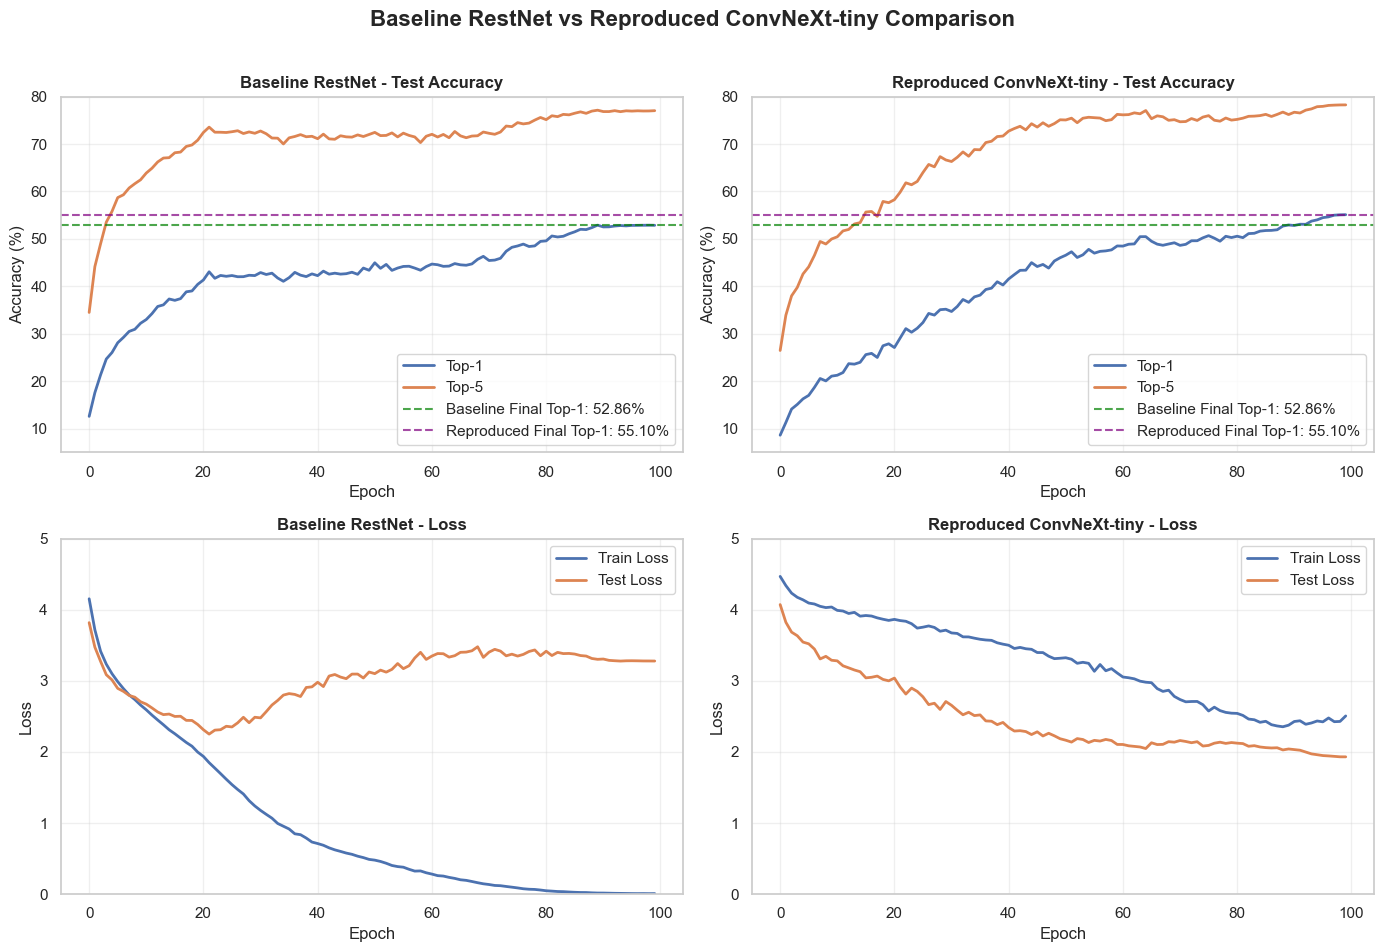

In [5]:
# Create 2x2 comparison: Baseline (1a) vs Reproduced ConvNeXt-tiny (1d)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Baseline RestNet vs Reproduced ConvNeXt-tiny Comparison', fontsize=16, fontweight='bold')

# Top-left: Baseline Test Accuracy (Top-1 and Top-5)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc1"], label="Top-1", linewidth=2)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc5"], label="Top-5", linewidth=2)
# Add horizontal lines showing final Top-1 accuracy for both models
final_acc1_1a = extracted_metrics_1a["test_acc1"][-1]
final_acc1_1d = extracted_metrics_1d["test_acc1"][-1]
axes[0, 0].axhline(y=final_acc1_1a, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Baseline Final Top-1: {final_acc1_1a:.2f}%')
axes[0, 0].axhline(y=final_acc1_1d, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Reproduced Final Top-1: {final_acc1_1d:.2f}%')
axes[0, 0].set_title("Baseline RestNet - Test Accuracy", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].set_ylim(5, 80)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Top-right: Reproduced ConvNeXt-tiny (1d) Test Accuracy (Top-1 and Top-5)
axes[0, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc1"], label="Top-1", linewidth=2)
axes[0, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc5"], label="Top-5", linewidth=2)
# Add horizontal lines showing final Top-1 accuracy for both models
axes[0, 1].axhline(y=final_acc1_1a, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Baseline Final Top-1: {final_acc1_1a:.2f}%')
axes[0, 1].axhline(y=final_acc1_1d, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Reproduced Final Top-1: {final_acc1_1d:.2f}%')
axes[0, 1].set_title("Reproduced ConvNeXt-tiny - Test Accuracy", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_ylim(5, 80)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: Baseline Train and Test Loss
axes[1, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["train_loss"], label="Train Loss", linewidth=2)
axes[1, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_loss"], label="Test Loss", linewidth=2)
axes[1, 0].set_title("Baseline RestNet - Loss", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_ylim(0, 5)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: Reproduced ConvNeXt-tiny (1d) Train and Test Loss
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["train_loss"], label="Train Loss", linewidth=2)
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_loss"], label="Test Loss", linewidth=2)
axes[1, 1].set_title("Reproduced ConvNeXt-tiny - Loss", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_ylim(0, 5)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## Extension 1

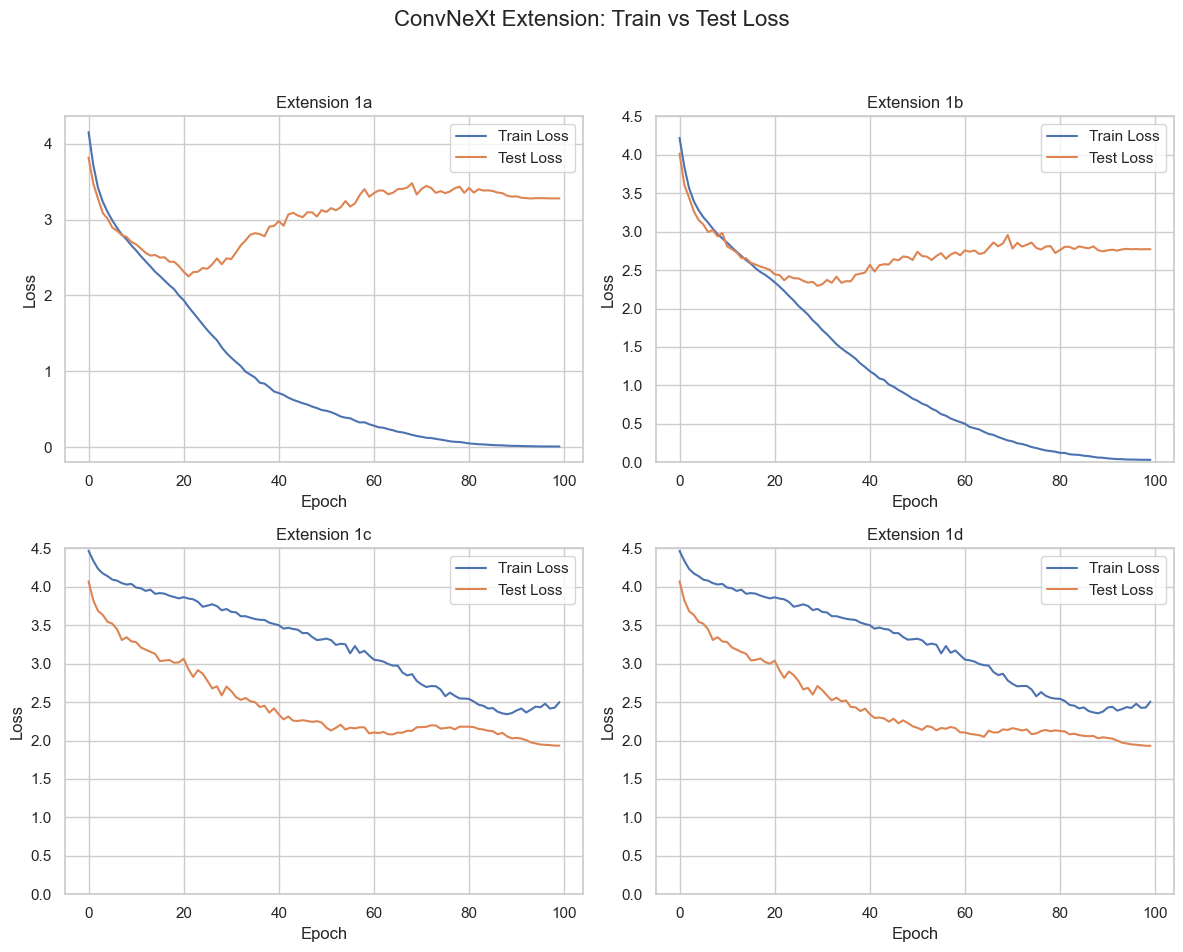

In [6]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Train vs Test Loss', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["train_loss"], label="Train Loss")
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_loss"], label="Test Loss")
axes[0, 0].set_title("Extension 1a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 1].set_ylim(0, 4.5)
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["train_loss"], label="Train Loss")
axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_loss"], label="Test Loss")
axes[0, 1].set_title("Extension 1b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_ylim(0, 4.5)
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["train_loss"], label="Train Loss")
axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_loss"], label="Test Loss")
axes[1, 0].set_title("Extension 1c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_ylim(0, 4.5)
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["train_loss"], label="Train Loss")
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_loss"], label="Test Loss")
axes[1, 1].set_title("Extension 1d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_ylim(0, 4.5)
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

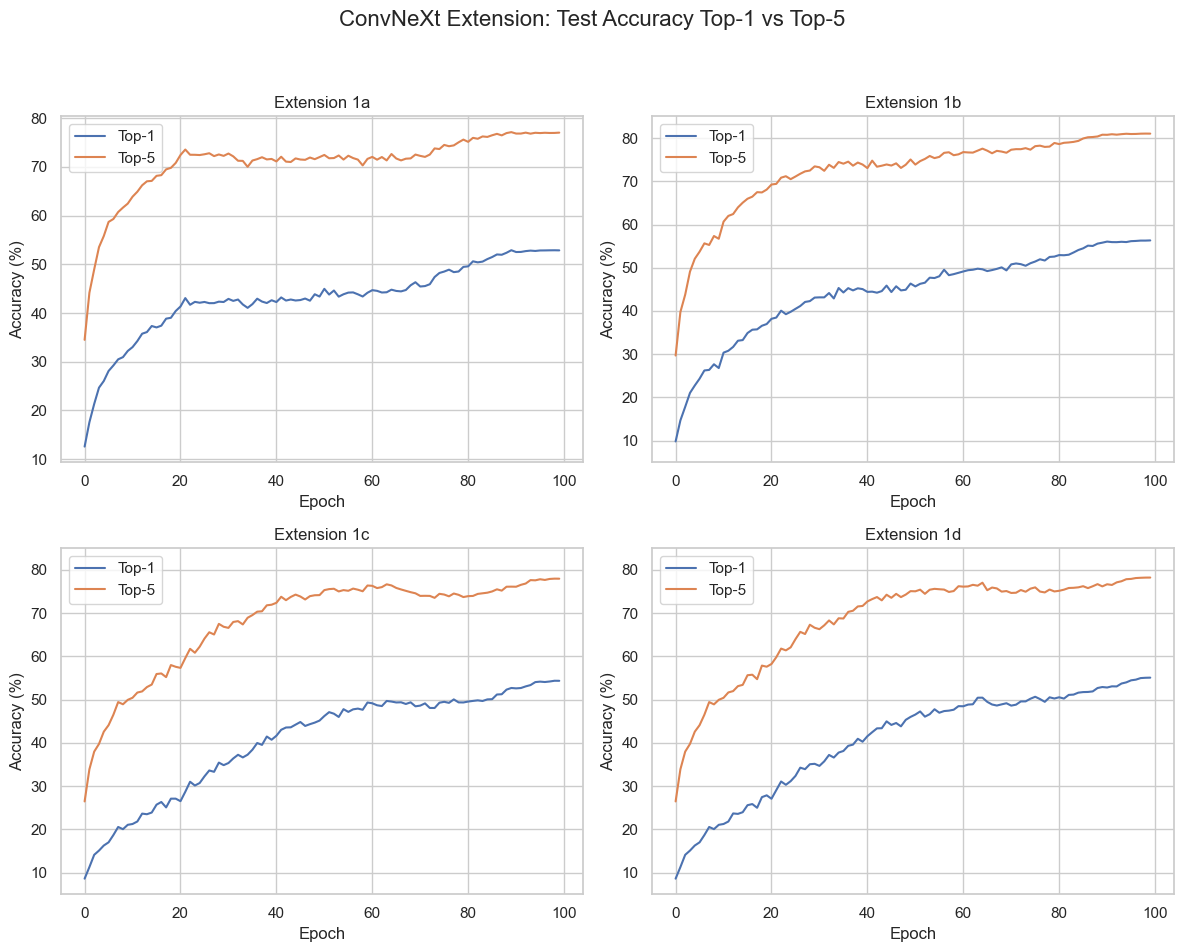

In [7]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Test Accuracy Top-1 vs Top-5', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc1"], label="Top-1")
axes[0, 0].plot(extracted_metrics_1a["epoch"], extracted_metrics_1a["test_acc5"], label="Top-5")
axes[0, 0].set_title("Extension 1a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 1].set_ylim(5, 85)
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_acc1"], label="Top-1")
axes[0, 1].plot(extracted_metrics_1b["epoch"], extracted_metrics_1b["test_acc5"], label="Top-5")
axes[0, 1].set_title("Extension 1b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_ylim(5, 85)
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_acc1"], label="Top-1")
axes[1, 0].plot(extracted_metrics_1c["epoch"], extracted_metrics_1c["test_acc5"], label="Top-5")
axes[1, 0].set_title("Extension 1c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].set_ylim(5, 85)
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc1"], label="Top-1")
axes[1, 1].plot(extracted_metrics_1d["epoch"], extracted_metrics_1d["test_acc5"], label="Top-5")
axes[1, 1].set_title("Extension 1d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].set_ylim(5, 85)
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
# summary_metrics
summary_metrics = {
    "Extensions": [
        "Baseline (no aug)",
        "+ Geometric aug",
        "+ Mixture aug",
        "Full recipe"
    ],
    "Max Top-1": [
        max(extracted_metrics_1a["test_acc1"]),
        max(extracted_metrics_1b["test_acc1"]),
        max(extracted_metrics_1c["test_acc1"]),
        max(extracted_metrics_1d["test_acc1"])
    ],
    "Train time (h:mm:ss)": [
        "0:50:01", "0:50:13", "0:48:30", "0:48:49"
    ]
}


In [9]:
df = pd.DataFrame(summary_metrics)
df["Delta Max Top-1"] = df["Max Top-1"] - df['Max Top-1'].shift(1)
df

,Extensions,Max Top-1,Train time (h:mm:ss),Delta Max Top-1
0,Baseline (no aug),52.890001,0:50:01,NaN
1,+ Geometric aug,56.320001,0:50:13,3.43
2,+ Mixture aug,54.380001,0:48:30,-1.94
3,Full recipe,55.100001,0:48:49,0.72


In [10]:
# Create summary table of final test_acc5 (Top-5 Accuracy)
summary_test_acc5 = {
    "Extension": [
        "1a (Baseline)",
        "1b (+ Geometric aug)",
        "1c (+ Mixture aug)",
        "1d (Full recipe)",
    ],
    "Final Test Acc5 (%)": [
        extracted_metrics_1a["test_acc5"][-1],
        extracted_metrics_1b["test_acc5"][-1],
        extracted_metrics_1c["test_acc5"][-1],
        extracted_metrics_1d["test_acc5"][-1],
    ]
}

df_summary_acc5 = pd.DataFrame(summary_test_acc5)
df_summary_acc5

,Extension,Final Test Acc5 (%)
0,1a (Baseline),77.030003
1,1b (+ Geometric aug),81.020002
2,1c (+ Mixture aug),77.990003
3,1d (Full recipe),78.250003


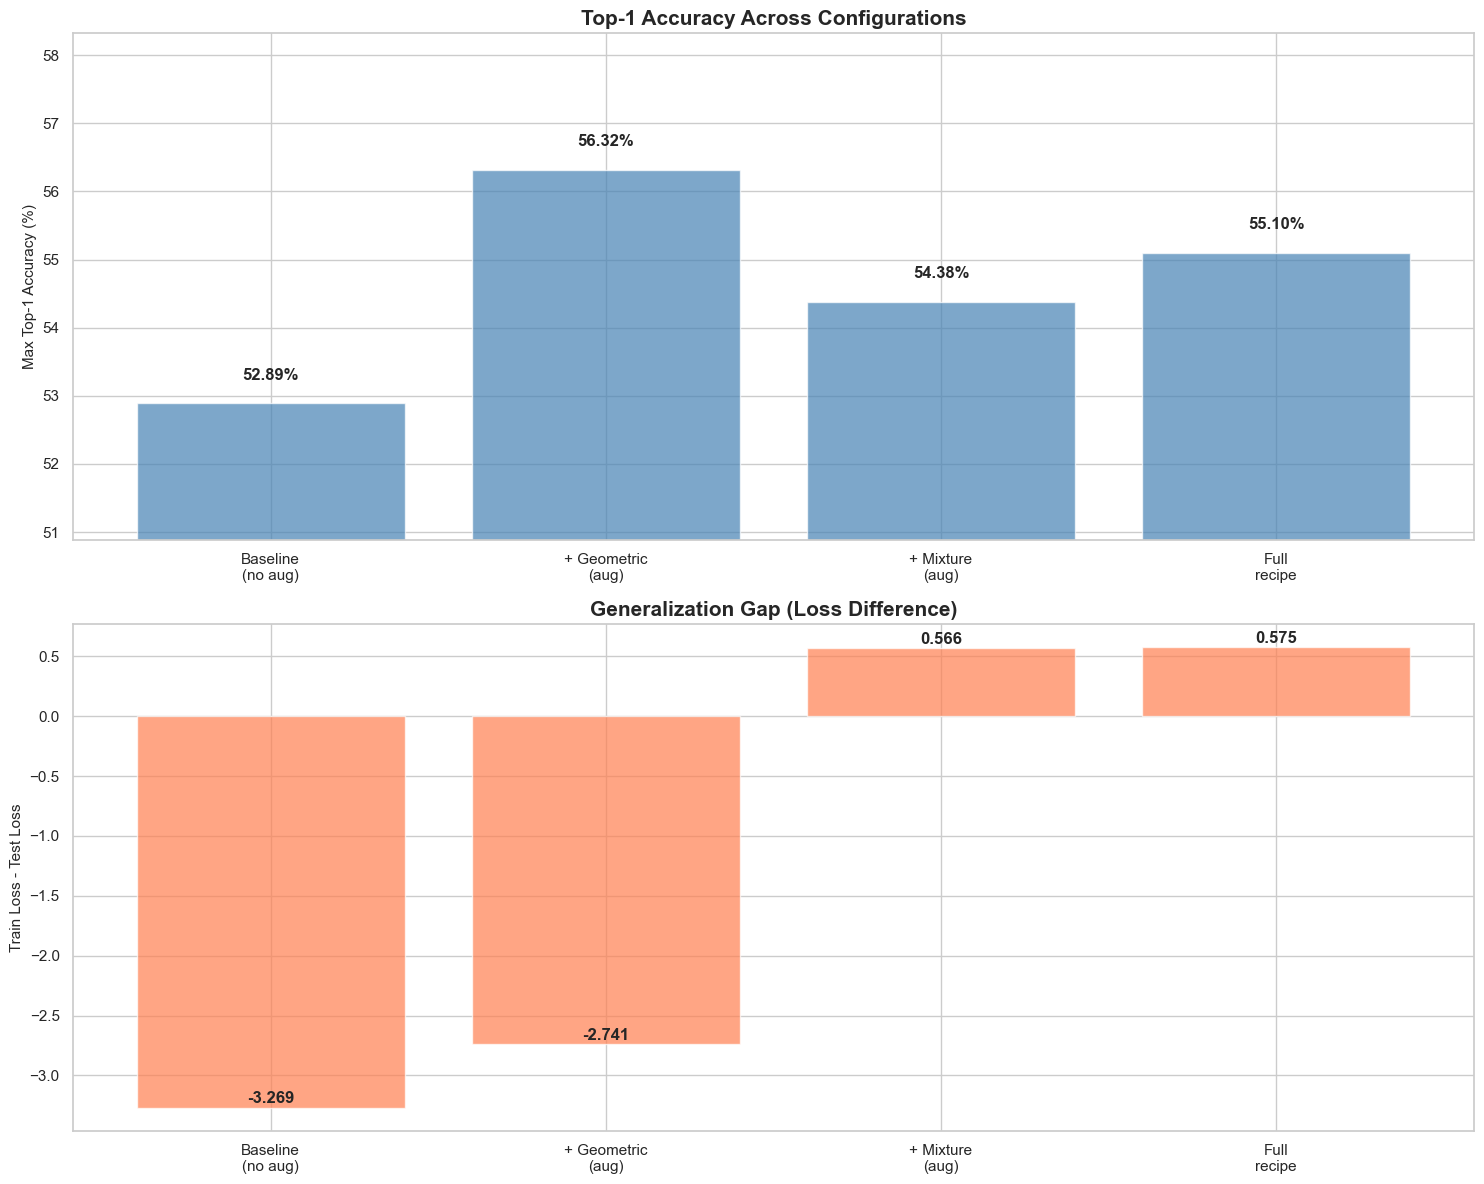

In [11]:
# Prepare data
extensions = ["Baseline\n(no aug)", "+ Geometric\n(aug)", "+ Mixture\n(aug)", "Full\nrecipe"]
max_top1 = [
    max(extracted_metrics_1a["test_acc1"]),
    max(extracted_metrics_1b["test_acc1"]),
    max(extracted_metrics_1c["test_acc1"]),
    max(extracted_metrics_1d["test_acc1"])
]

# Calculate generalization gap (train_loss - test_loss at final epoch)
gen_gaps = [
    extracted_metrics_1a["train_loss"][-1] - extracted_metrics_1a["test_loss"][-1],
    extracted_metrics_1b["train_loss"][-1] - extracted_metrics_1b["test_loss"][-1],
    extracted_metrics_1c["train_loss"][-1] - extracted_metrics_1c["test_loss"][-1],
    extracted_metrics_1d["train_loss"][-1] - extracted_metrics_1d["test_loss"][-1],
]

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Subplot 1: Top-1 Accuracy
x = np.arange(len(extensions))
axes[0].bar(x, max_top1, color='steelblue', alpha=0.7)
axes[0].set_ylabel('Max Top-1 Accuracy (%)', fontsize=11)
axes[0].set_title('Top-1 Accuracy Across Configurations', fontsize=15, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(extensions)
axes[0].set_ylim([min(max_top1) - 2, max(max_top1) + 2])
for i, v in enumerate(max_top1):
    axes[0].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Generalization Gap
axes[1].bar(x, gen_gaps, color='coral', alpha=0.7)
axes[1].set_ylabel('Train Loss - Test Loss', fontsize=11)
axes[1].set_title('Generalization Gap (Loss Difference)', fontsize=15, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(extensions)
for i, v in enumerate(gen_gaps):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Extension 2

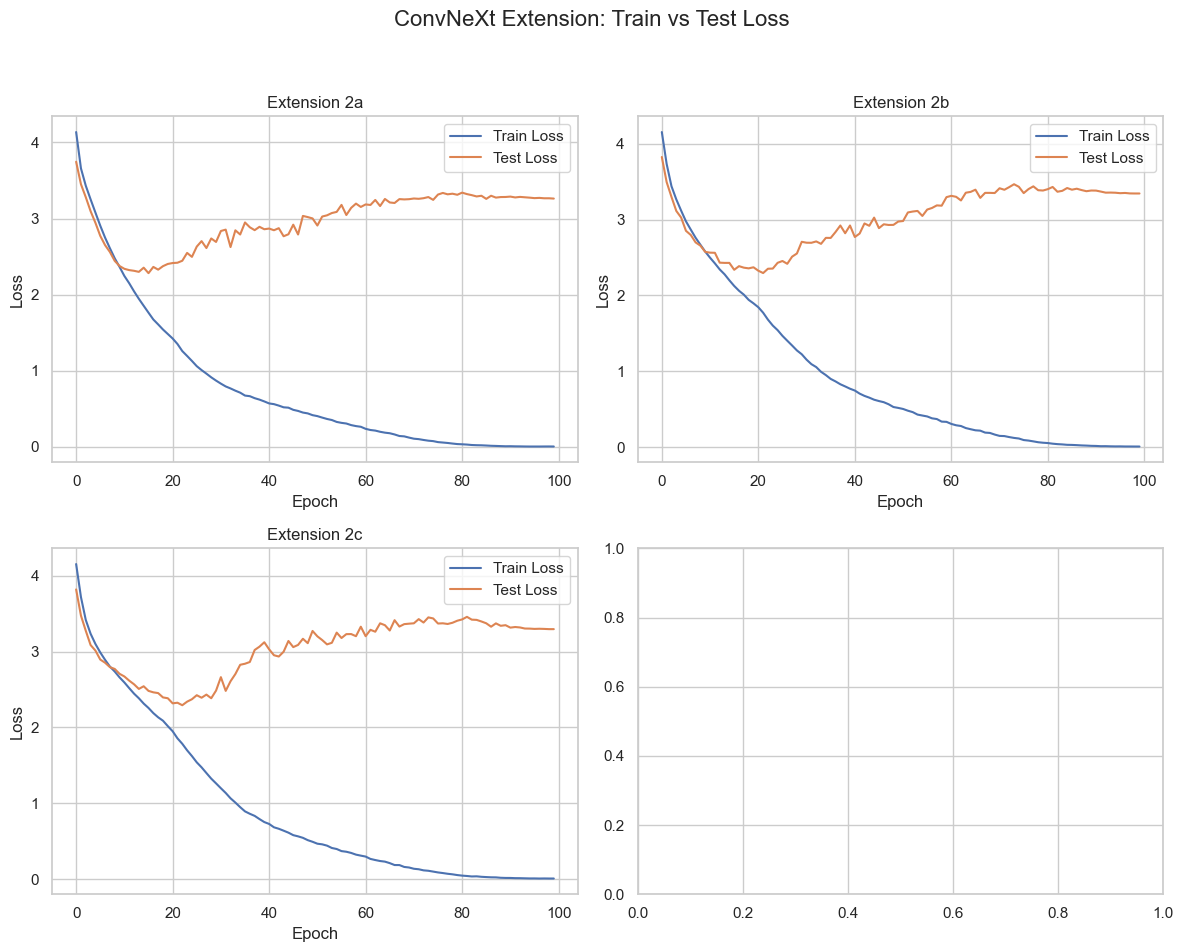

In [12]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Train vs Test Loss', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_2a["epoch"], extracted_metrics_2a["train_loss"], label="Train Loss")
axes[0, 0].plot(extracted_metrics_2a["epoch"], extracted_metrics_2a["test_loss"], label="Test Loss")
axes[0, 0].set_title("Extension 2a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_2b["epoch"], extracted_metrics_2b["train_loss"], label="Train Loss")
axes[0, 1].plot(extracted_metrics_2b["epoch"], extracted_metrics_2b["test_loss"], label="Test Loss")
axes[0, 1].set_title("Extension 2b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_2c["epoch"], extracted_metrics_2c["train_loss"], label="Train Loss")
axes[1, 0].plot(extracted_metrics_2c["epoch"], extracted_metrics_2c["test_loss"], label="Test Loss")
axes[1, 0].set_title("Extension 2c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

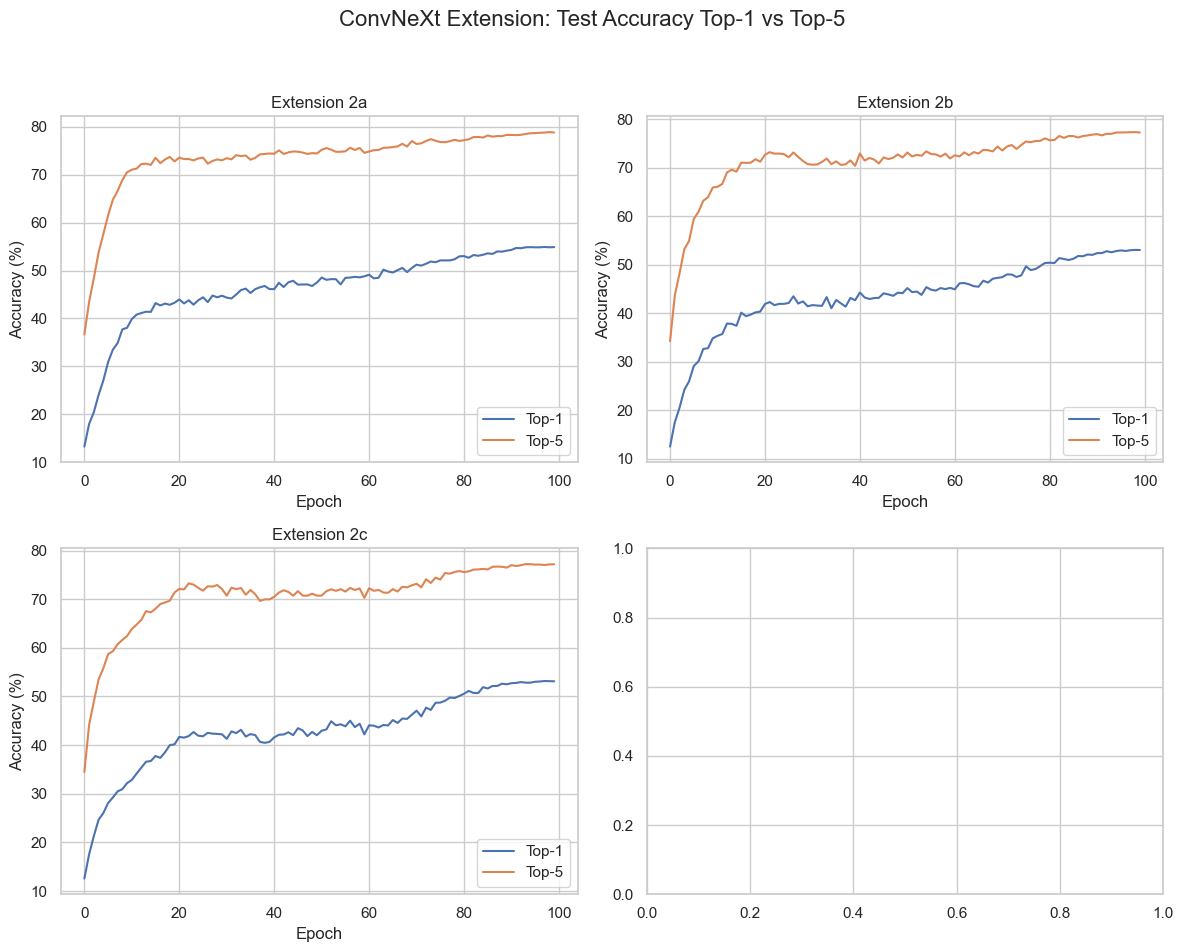

In [13]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Test Accuracy Top-1 vs Top-5', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_2a["epoch"], extracted_metrics_2a["test_acc1"], label="Top-1")
axes[0, 0].plot(extracted_metrics_2a["epoch"], extracted_metrics_2a["test_acc5"], label="Top-5")
axes[0, 0].set_title("Extension 2a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_2b["epoch"], extracted_metrics_2b["test_acc1"], label="Top-1")
axes[0, 1].plot(extracted_metrics_2b["epoch"], extracted_metrics_2b["test_acc5"], label="Top-5")
axes[0, 1].set_title("Extension 2b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_2c["epoch"], extracted_metrics_2c["test_acc1"], label="Top-1")
axes[1, 0].plot(extracted_metrics_2c["epoch"], extracted_metrics_2c["test_acc5"], label="Top-5")
axes[1, 0].set_title("Extension 2c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
# summary_metrics
summary_metrics_ext2 = {
    "Extensions": [
        "Full ConvNeXt",
        "LayerNorm → BN",
        "GELU → ReLU",
        "Restore 1×1 conv"
    ],
    "Max Top-1": [
        max(extracted_metrics_1a["test_acc1"]),
        max(extracted_metrics_2a["test_acc1"]),
        max(extracted_metrics_2b["test_acc1"]),
        max(extracted_metrics_2c["test_acc1"])
    ],
    "Paper (ImageNet) Delta": [
        "0", "-0.6", "-0.4", "-0.3"
    ]
}


In [15]:
df_ext2 = pd.DataFrame(summary_metrics_ext2)
df_ext2["Delta Max Top-1"] = df_ext2["Max Top-1"] - df_ext2["Max Top-1"].iloc[0]
df_ext2

,Extensions,Max Top-1,Paper (ImageNet) Delta,Delta Max Top-1
0,Full ConvNeXt,52.890001,0,0.000000
1,LayerNorm → BN,54.910000,-0.6,2.019999
2,GELU → ReLU,53.040000,-0.4,0.149999
3,Restore 1×1 conv,53.180000,-0.3,0.289999


## Extension 3

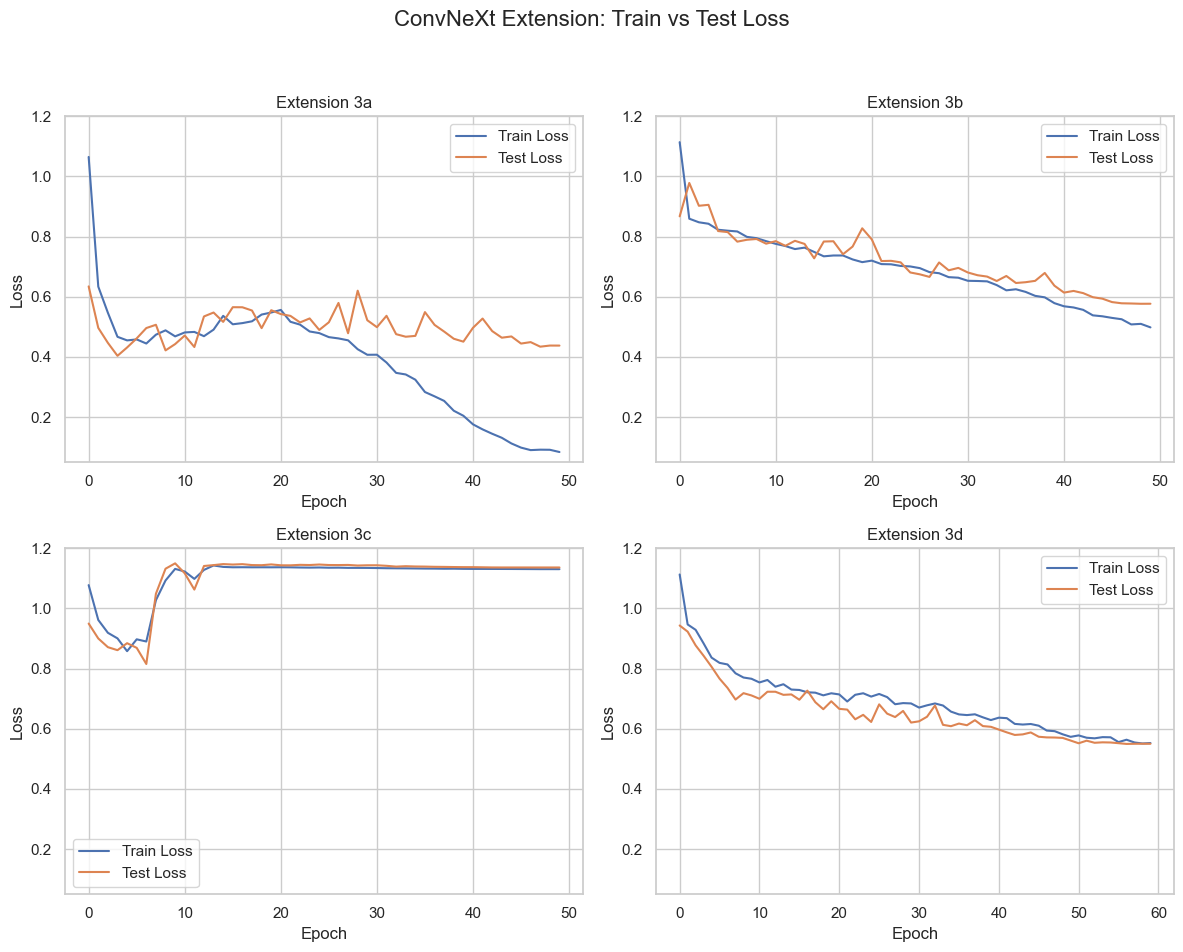

In [37]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Train vs Test Loss', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_3a["epoch"], extracted_metrics_3a["train_loss"], label="Train Loss")
axes[0, 0].plot(extracted_metrics_3a["epoch"], extracted_metrics_3a["test_loss"], label="Test Loss")
axes[0, 0].set_title("Extension 3a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_ylim(0.05, 1.2)
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_3b["epoch"], extracted_metrics_3b["train_loss"], label="Train Loss")
axes[0, 1].plot(extracted_metrics_3b["epoch"], extracted_metrics_3b["test_loss"], label="Test Loss")
axes[0, 1].set_title("Extension 3b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].set_ylim(0.05, 1.2)
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_3c["epoch"], extracted_metrics_3c["train_loss"], label="Train Loss")
axes[1, 0].plot(extracted_metrics_3c["epoch"], extracted_metrics_3c["test_loss"], label="Test Loss")
axes[1, 0].set_title("Extension 3c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_ylim(0.05, 1.2)
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_3d["epoch"], extracted_metrics_3d["train_loss"], label="Train Loss")
axes[1, 1].plot(extracted_metrics_3d["epoch"], extracted_metrics_3d["test_loss"], label="Test Loss")
axes[1, 1].set_title("Extension 3d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].set_ylim(0.05, 1.2)
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

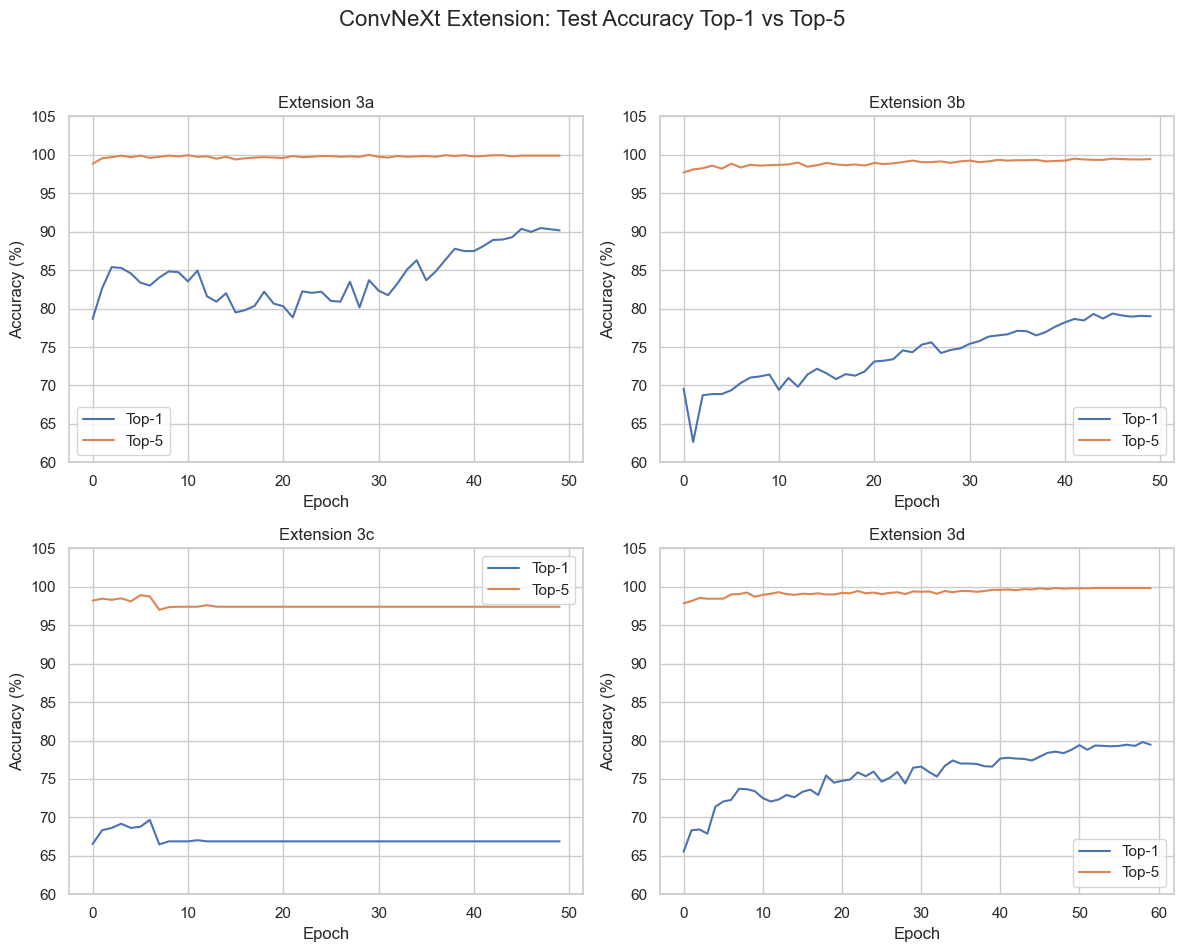

In [21]:
# Initialize Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('ConvNeXt Extension: Test Accuracy Top-1 vs Top-5', fontsize=16)

# Define the subplots (row, col)
axes[0, 0].plot(extracted_metrics_3a["epoch"], extracted_metrics_3a["test_acc1"], label="Top-1")
axes[0, 0].plot(extracted_metrics_3a["epoch"], extracted_metrics_3a["test_acc5"], label="Top-5")
axes[0, 0].set_title("Extension 3a")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy (%)")
axes[0, 0].set_ylim(60, 105)
axes[0, 0].legend()

axes[0, 1].plot(extracted_metrics_3b["epoch"], extracted_metrics_3b["test_acc1"], label="Top-1")
axes[0, 1].plot(extracted_metrics_3b["epoch"], extracted_metrics_3b["test_acc5"], label="Top-5")
axes[0, 1].set_title("Extension 3b")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_ylim(60, 105)
axes[0, 1].legend()

axes[1, 0].plot(extracted_metrics_3c["epoch"], extracted_metrics_3c["test_acc1"], label="Top-1")
axes[1, 0].plot(extracted_metrics_3c["epoch"], extracted_metrics_3c["test_acc5"], label="Top-5")
axes[1, 0].set_title("Extension 3c")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].set_ylim(60, 105)
axes[1, 0].legend()

axes[1, 1].plot(extracted_metrics_3d["epoch"], extracted_metrics_3d["test_acc1"], label="Top-1")
axes[1, 1].plot(extracted_metrics_3d["epoch"], extracted_metrics_3d["test_acc5"], label="Top-5")
axes[1, 1].set_title("Extension 3d")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].set_ylim(60, 105)
axes[1, 1].legend()

# Clean up layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [18]:
"""From logs/metric3x.txt
Accuracy: 0.8997506234413966
Macro F1: 0.8351842963299881

Model: resnet50
Accuracy: 0.7925187032418952
Macro F1: 0.562928389452494


Model: swin_tiny_patch4_window7_224
Accuracy: 0.6962593516209477
Macro F1: 0.2280011852923088


Model: swin_tiny_patch4_window7_224
Accuracy: 0.7965087281795511
Macro F1: 0.6200934460370163
"""

'From logs/metric3x.txt\nAccuracy: 0.8997506234413966\nMacro F1: 0.8351842963299881\n\nModel: resnet50\nAccuracy: 0.7925187032418952\nMacro F1: 0.562928389452494\n\n\nModel: swin_tiny_patch4_window7_224\nAccuracy: 0.6962593516209477\nMacro F1: 0.2280011852923088\n\n\nModel: swin_tiny_patch4_window7_224\nAccuracy: 0.7965087281795511\nMacro F1: 0.6200934460370163\n'

In [19]:
# summary_metrics
summary_metrics_ext3 = {
    "Extensions": [
        "ConvNeXt-Tiny",
        "ResNet-50",
        "Swin-Tiny",
        "Swin-Tiny with slower learning rate, more epoch, and stronger regularization"
    ],
    "Max Top-1": [
        max(extracted_metrics_3a["test_acc1"]),
        max(extracted_metrics_3b["test_acc1"]),
        max(extracted_metrics_3c["test_acc1"]),
        max(extracted_metrics_3d["test_acc1"])
    ],
    "Macro F1": [
        "0.8351842963299881", "0.562928389452494", "0.2280011852923088", "0.6200934460370163"
    ]
}


In [20]:
df_ext3 = pd.DataFrame(summary_metrics_ext3)
df_ext3

,Extensions,Max Top-1,Macro F1
0,ConvNeXt-Tiny,90.473819,0.8351842963299881
1,ResNet-50,79.351623,0.562928389452494
2,Swin-Tiny,69.675813,0.2280011852923088
3,"Swin-Tiny with slower learning rate, more epoc...",79.800501,0.6200934460370163
